## Multi-Armed Bandit: Exploração de Algoritmos para Oferta de Carteira

O projeto visa oferecer **seguro**, **investimento** ou **crédito**, equilibrando exploração e explotação, aprendendo com respostas observadas e sem congelar a decisão em regras estáticas.

Algoritmos testados:

- **LinUCB**
- **Thompson Sampling**
- **Baseline Determinístico**

Braços (ações): `seguro`, `investimento`, `credito`

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 5)

DATA_PATH = "../data/golden_set/golden_clients.csv"
ARMS = ['seguro', 'investimento', 'credito']

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"{len(df):,} clientes | {len(df.columns)} colunas")

2,595 clientes | 48 colunas


In [3]:
df[['cod_cliente','segmento','renda_estimada_anual_brl','idade','segmentos_sinteticos']].head()

,cod_cliente,segmento,renda_estimada_anual_brl,idade,segmentos_sinteticos
0,100870,02 - VAREJO,47821.31,45,"[""SEG-CREDITO-ATIVO"", ""SEG-INVESTIDOR-INICIANT..."
1,1186912,03 - UNIVERSITARIO,146222.00,23,"[""SEG-JOVEM"", ""SEG-CREDITO-ATIVO"", ""SEG-SEM-CA..."
2,952537,03 - UNIVERSITARIO,189376.26,26,"[""SEG-JOVEM"", ""SEG-ALTA-RENDA"", ""SEG-CREDITO-A..."
3,1383107,02 - VAREJO,36226.77,36,"[""SEG-SEM-CARTAO"", ""SEG-INVESTIDOR-INICIANTE"",..."
4,904395,02 - VAREJO,11466.07,51,"[""SEG-SEM-CARTAO"", ""SEG-INVESTIDOR-INICIANTE"",..."


### Modelagem da recompensa composta

**Recompensa composta com pesos ajustáveis**:
$$r = \alpha \cdot \frac{\text{receita observada}}{V_{max}} + \beta \cdot \text{conversão}$$

- `α` prioriza **receita** · `β` prioriza **conversão** · com `α+β=1` a recompensa fica em `[0,1]`
- Receita só se realiza **se o cliente converter**

Para o contexto de negócio, a **conversão e receita variam por segmento e renda**:

| Produto | Conversão | Receita | Perfil |
|---|---|---|---|
| Seguro | média | moderada, escala leve c/ renda | equilibrado (família, sênior) |
| Investimento | baixa (alta só p/ rico) | **alta**, escala forte c/ renda | alta receita, baixa conversão |
| Crédito | **alta** | moderada, **inversa** à renda | alta conversão, ticket menor |

In [4]:
# Parâmetros da recompensa
ALPHA = 0.6   # peso receita
BETA  = 0.4   # peso conversão
V_MAX = 5000.0

In [5]:
# Criando funções para simular a probabilidade de conversão e receita esperada por produto, com base nos segmentos e renda do cliente.
def parse_segs(c):
    """Parseia os segmentos sintéticos do cliente em um set de strings."""
    try: 
        return set(ast.literal_eval(c['segmentos_sinteticos']))
    except Exception: 
        return set()

def true_conv(client):
    """Simula a probabilidade real de conversão por produto."""
    segs = parse_segs(client)
    renda = client['renda_estimada_anual_brl']
    
    ps = 0.10
    if 'SEG-PERFIL-FAMILIAR' in segs: 
        ps += 0.15
    if 'SEG-SENIOR' in segs:          
        ps += 0.18
    if 'SEG-PROPRIETARIO' in segs:    
        ps += 0.12
    if renda > 80_000:                
        ps += 0.05
    if 'SEG-JOVEM' in segs:           
        ps -= 0.04
        
    pi = 0.06
    if 'SEG-INVESTIDOR-EXPERIENTE' in segs: 
        pi += 0.18
    if 'SEG-ALTA-RENDA' in segs:            
        pi += 0.12
    if 'SEG-VIP' in segs:                   
        pi += 0.10
    if 'SEG-INVESTIDOR-INICIANTE' in segs:  
        pi += 0.06
    if renda > 100_000:                     
        pi += 0.08
        
    pc = 0.16
    if 'SEG-CREDITO-ATIVO' in segs: 
        pc += 0.20
    if 'SEG-SEM-CARTAO' in segs:    
        pc += 0.12
    if 'SEG-JOVEM' in segs:         
        pc += 0.10
    if 'SEG-SENIOR' in segs:        
        pc -= 0.08
    if renda < 40_000:               
        pc += 0.06
    if renda > 150_000:              
        pc -= 0.08
    return np.clip([ps, pi, pc], 0.01, 0.95)

def true_revenue(client):
    """Ticket de receita (R$) por produto (depende da renda)."""
    r = min(client['renda_estimada_anual_brl'] / 200_000, 1.5) # normaliza a renda em [0, 1.5] 
    return np.array([
        800 + 1200 * r,            # seguro
        1000 + 3500 * r,           # investimento (forte c/ renda)
        max(2200 - 900 * r, 300),  # credito (inverso à renda)
    ])

In [6]:
clients = df.to_dict('records')
CONV = np.array([true_conv(c)    for c in clients]) # probabilidades de conversão por produto
REV  = np.array([true_revenue(c) for c in clients]) # receita esperada por produto
EXP_R = CONV * (ALPHA * (REV / V_MAX) + BETA)   # recompensa final esperada
BEST_ARM = EXP_R.argmax(axis=1)                 # braço ótimo para cada cliente 

print("Conversão média :", dict(zip(ARMS, CONV.mean(0).round(3))))
print("Receita média R$:", dict(zip(ARMS, REV.mean(0).round(0))))
print("Reward esperado :", dict(zip(ARMS, EXP_R.mean(0).round(3))))
print("Melhor braço    :", dict(zip(ARMS, np.bincount(BEST_ARM, minlength=3))))

Conversão média : {'seguro': np.float64(0.256), 'investimento': np.float64(0.195), 'credito': np.float64(0.346)}
Receita média R$: {'seguro': np.float64(1312.0), 'investimento': np.float64(2494.0), 'credito': np.float64(1816.0)}
Reward esperado : {'seguro': np.float64(0.144), 'investimento': np.float64(0.147), 'credito': np.float64(0.215)}
Melhor braço    : {'seguro': np.int64(395), 'investimento': np.int64(554), 'credito': np.int64(1646)}


In [7]:
rows = []

# Criando uma tabela de sensibilidade do melhor braço conforme o knob α/β
for a in [0.0, 0.3, 0.6, 0.9, 1.0]:
    er = CONV * (a * (REV / V_MAX) + (1 - a))
    dist = np.bincount(er.argmax(1), minlength=3)
    rows.append([f"{a:.1f}", f"{1-a:.1f}", *dist])
    
sens = pd.DataFrame(rows, columns=['α (receita)', 'β (conversão)', *ARMS])
print("Distribuição do melhor braço conforme α/β:")
sens

Distribuição do melhor braço conforme α/β:


,α (receita),β (conversão),seguro,investimento,credito
0,0.0,1.0,692,298,1605
1,0.3,0.7,527,415,1653
2,0.6,0.4,395,554,1646
3,0.9,0.1,229,725,1641
4,1.0,0.0,138,794,1663


### Baseline determinístico

Regras de negócio fixas com política de controle.

In [8]:
def deterministic_rule(client):
    """
    Regra determinística para escolher o braço ótimo com base nos segmentos e renda do cliente.
    Retorna 0=seguro, 1=investimento, 2=credito.
    """
    segs = parse_segs(client); renda = client['renda_estimada_anual_brl']
    seg = client['segmento']
    
    if seg == '01 - ALTA RENDA' or 'SEG-VIP' in segs:          
        return 1 
    if 'SEG-INVESTIDOR-EXPERIENTE' in segs:                    
        return 1 
    if 'SEG-SENIOR' in segs or 'SEG-PROPRIETARIO' in segs:     
        return 0 
    if 'SEG-CREDITO-ATIVO' in segs or 'SEG-SEM-CARTAO' in segs: 
        return 2 
    if 'SEG-JOVEM' in segs:                                    
        return 2 
    if 'SEG-PERFIL-FAMILIAR' in segs:                          
        return 0 
    if renda > 80_000:                                         
        return 1 
    return 2  # default: crédito

### Thompson Sampling

A incerteza é tratada de forma probabilística.

Começamos com uma **crença neutra** na qual nenhum produto é favorecido a priori.

**Adaptação por recompensa:** nossa recompensa composta é contínua no intervalo de `[0,1]`. Tratamos a recompensa como probabilidade de sucesso e aplicamos a técnica de Bernoulli para atualizar o Beta.

In [9]:
class ThompsonSampling:
    def __init__(self, n_arms):
        self.alpha = np.ones(n_arms)   # prior Beta(1,1): crença neutra
        self.beta  = np.ones(n_arms)

    def select(self, x=None):
        """Seleciona o braço a ser puxado com base na amostra da distribuição Beta para cada braço."""
        return int(np.argmax(np.random.beta(self.alpha, self.beta)))

    def update(self, arm, reward, x=None):
        """Atualiza os parâmetros da distribuição Beta com base no resultado observado (reward)."""
        sucesso = int(np.random.random() < reward)  # reward entre 0 e 1
        if sucesso: 
            self.alpha[arm] += 1
        else:       
            self.beta[arm] += 1

### LinUCB

Assume que a recompensa esperada de cada braço é linear nas features e a cada rodada escolhe o braço que maximiza estimativa + bônus de incerteza.

Se não tivermos dados então a decisão é decidida pela incerteza. O LinUCB **explora naturalmente** os braços pouco vistos.

In [10]:
class LinUCB:
    def __init__(self, n_arms, d, alpha_ucb=1.0, lam=1.0):
        self.n = n_arms 
        self.d = d
        self.alpha_ucb = alpha_ucb
        self.A = [np.eye(d) * lam for _ in range(n_arms)]
        self.b = [np.zeros(d)     for _ in range(n_arms)]

    def select(self, x):
        """Seleciona o braço a ser puxado com base na amostra da distribuição Beta para cada braço."""
        best_p, best_a = -np.inf, 0
        for a in range(self.n):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            p = theta @ x + self.alpha_ucb * np.sqrt(x @ A_inv @ x) # UCB calculado com base na incerteza da estimativa
            if p > best_p:
                best_p, best_a = p, a
        return best_a

    def update(self, arm, reward, x):
        """Atualiza os parâmetros do modelo com base na observação (reward) e nas features (x)."""
        self.A[arm] += np.outer(x, x)
        self.b[arm] += reward * x

### Features de contexto para o LinUCB
LinUCB precisa de um vetor de contexto  com as variáveis dos usuários.

Padronizamos as numéricas, incluímos flags de produtos já contratados e *one-hot* dos segmentos sintéticos. 

In [11]:
num_cols = ['idade', 'renda_estimada_anual_brl', 'tempo_relacionamento_meses']
flag_cols = ['possui_cartao_credito', 'possui_conta_investimento','possui_fundo_investimento', 'possui_conta_corrente']
seg_keys = ['SEG-JOVEM','SEG-SENIOR','SEG-ALTA-RENDA','SEG-VIP','SEG-CREDITO-ATIVO','SEG-INVESTIDOR-EXPERIENTE','SEG-PERFIL-FAMILIAR']

# padronização das features numéricas
num = df[num_cols].astype(float)
num = (num - num.mean()) / num.std()   

def build_features(idx, client):
    feat = [1.0] # viés
    feat += num.iloc[idx].tolist() # numéricas
    feat += [float(client[f]) if not pd.isna(client[f]) else 0.0 for f in flag_cols]
    segs = parse_segs(client)
    feat += [1.0 if k in segs else 0.0 for k in seg_keys] # segmentos
    return np.array(feat)

X = np.array([build_features(i, c) for i, c in enumerate(clients)])
D = X.shape[1]
print(f"Vetor de contexto: {D} dimensões")

Vetor de contexto: 15 dimensões


### Simulação e métricas

Rodamos cada política por `N_ROUNDS` ofertas (reciclando a base) e medimos:
- recompensa acumulada
- regret
- taxa de exploração
- conversão
- receita simulada em R$

In [12]:
def observe(i, arm):
    """Puxa o braço p/ o cliente i. Retorna (reward, conversao, receita)."""
    converted = int(np.random.random() < CONV[i][arm])
    revenue   = converted * REV[i][arm]
    reward    = ALPHA * (revenue / V_MAX) + BETA * converted
    return reward, converted, revenue

In [13]:
N_ROUNDS = 5000

def run_policy(kind, n_rounds=N_ROUNDS, alpha_ucb=1.0):
    if kind == 'ts':     
        agent = ThompsonSampling(3)
    elif kind == 'linucb': 
        agent = LinUCB(3, D, alpha_ucb=alpha_ucb)
    else:                  
        agent = None

    hist_r, hist_c, hist_rev, choices, explored = [], [], [], [], []
    cum_r = cum_c = cum_rev = 0
    last_best = None

    for t in range(n_rounds):
        i = t % len(clients) # ciclo pelos clientes
        x = X[i] # vetor de contexto do cliente i
        if kind == 'det':
            # Escolhe o braço com base na regra determinística definida anteriormente.    
            arm = deterministic_rule(clients[i])
        elif kind == 'oracle':
            # Escolhe o braço ótimo com base na recompensa esperada conhecida (oracle). 
            arm = BEST_ARM[i]
        else:
            # Seleciona o braço a ser puxado com base no algoritmo de aprendizado (Thompson Sampling ou LinUCB).                   
            arm = agent.select(x)

        r, c, rev = observe(i, arm)
        if agent is not None:
            # Atualiza os parâmetros do modelo com base na observação (reward) e nas features (x).
            agent.update(arm, r, x)

        # exploração = escolheu algo diferente do melhor braço estimado/conhecido
        if kind == 'linucb':
            greedy = int(np.argmax([ (np.linalg.inv(agent.A[a])@agent.b[a]) @ x for a in range(3)]))
            explored.append(int(arm != greedy))
        elif kind == 'ts':
            explored.append(int(arm != int(np.argmax(agent.alpha/(agent.alpha+agent.beta)))))
        else:
            explored.append(0)

        cum_r += r
        cum_c += c 
        cum_rev += rev
        
        hist_r.append(cum_r)
        hist_c.append(cum_c)
        hist_rev.append(cum_rev)
        choices.append(arm)

    return dict(
        reward=np.array(hist_r), 
        conv=np.array(hist_c),
        rev=np.array(hist_rev), 
        choices=np.array(choices),
        explore_rate=np.mean(explored)
        )

In [14]:
np.random.seed(7)
res = {
    'Baseline':  run_policy('det'),
    'Thompson':  run_policy('ts'),
    'LinUCB':    run_policy('linucb'),
    'Oracle':    run_policy('oracle'),
}

print(f"{'Política':<12}{'Reward':>10}{'Conv%':>8}{'Receita R$':>15}{'Exploração':>12}")
for name, r in res.items():
    print(f"{name:<12}{r['reward'][-1]:>10.1f}{r['conv'][-1]/N_ROUNDS*100:>7.1f}%"
          f"{r['rev'][-1]:>15,.0f}{r['explore_rate']*100:>11.1f}%")

Política        Reward   Conv%     Receita R$  Exploração
Baseline        1171.9   36.6%      3,669,037        0.0%
Thompson        1076.1   34.8%      3,174,108        5.6%
LinUCB          1244.9   36.6%      4,277,327        9.6%
Oracle          1289.0   38.4%      4,338,342        0.0%


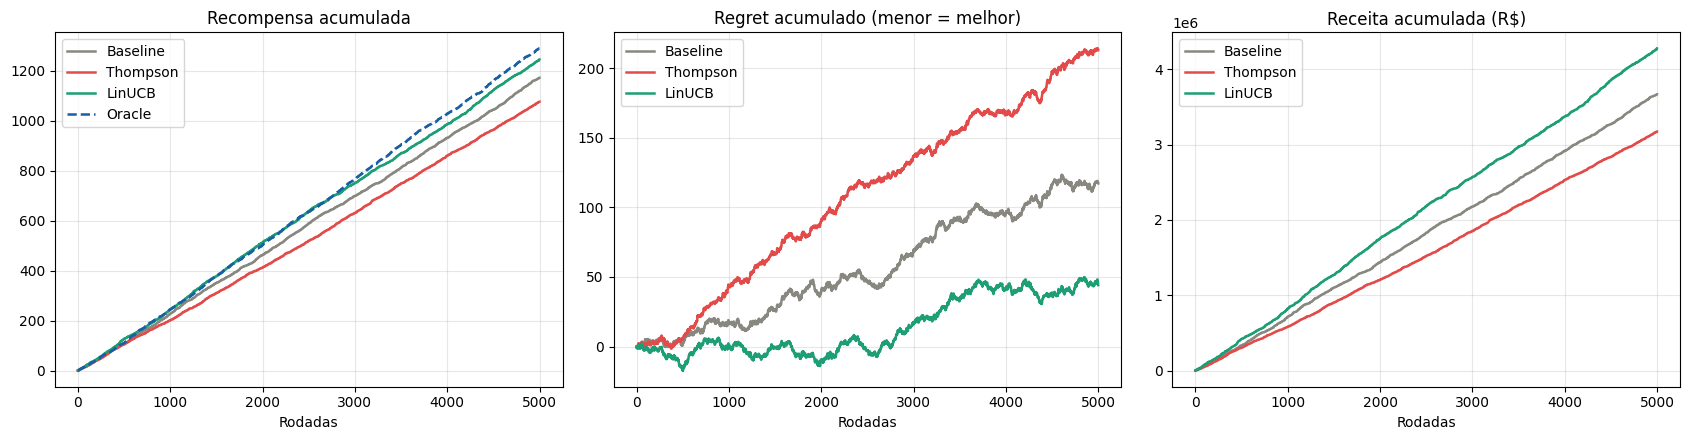

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
cores = {'Baseline':'#888780','Thompson':'#E24B4A','LinUCB':'#1D9E75','Oracle':'#185FA5'}

for name, r in res.items():
    st = '--' if name == 'Oracle' else '-'
    axes[0].plot(r['reward'], st, label=name, color=cores[name], lw=1.8)
axes[0].set_title('Recompensa acumulada'); axes[0].set_xlabel('Rodadas'); axes[0].legend(); axes[0].grid(alpha=0.3)

orc = res['Oracle']['reward']
for name, r in res.items():
    if name == 'Oracle': continue
    axes[1].plot(orc - r['reward'], label=name, color=cores[name], lw=1.8)
axes[1].set_title('Regret acumulado (menor = melhor)'); axes[1].set_xlabel('Rodadas'); axes[1].legend(); axes[1].grid(alpha=0.3)

for name, r in res.items():
    if name == 'Oracle': continue
    axes[2].plot(r['rev'], label=name, color=cores[name], lw=1.8)
axes[2].set_title('Receita acumulada (R$)'); axes[2].set_xlabel('Rodadas'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Eleição do melhor modelo

Uma simulação única é ruidosa. Para eleger de forma justa, rodamos cada política em **N_RUNS sementes independentes** e comparamos média ± desvio do reward (a mesma semente alimenta todas as políticas em cada rodada (comparação pareada)).

In [16]:
N_RUNS = 25
scores = {k: [] for k in ['Baseline', 'Thompson', 'LinUCB']}

for seed in range(N_RUNS):
    for name, kind in [('Baseline','det'), ('Thompson','ts'), ('LinUCB','linucb')]:
        np.random.seed(seed)
        scores[name].append(run_policy(kind)['reward'][-1])
        
np.random.seed(0)
oracle_ref = run_policy('oracle')['reward'][-1]

resumo = pd.DataFrame({n: {'media': np.mean(v), 'desvio': np.std(v),
                           'min': np.min(v), 'max': np.max(v)}
                       for n, v in scores.items()}).T.sort_values('media', ascending=False)

resumo['% do oracle'] = (resumo['media'] / oracle_ref * 100).round(1)
resumo = resumo.round(2)
print(f"Teto (oracle): {oracle_ref:.1f}\n")
print(resumo)

Teto (oracle): 1289.7

            media  desvio      min      max  % do oracle
LinUCB    1210.34   28.84  1156.19  1261.16         93.8
Baseline  1163.83   25.50  1115.95  1214.22         90.2
Thompson  1040.04   23.73  1000.85  1093.69         80.6


In [17]:
campeao = resumo.index[0]
print("\n" + "="*50)
print(f"  🏆 ELEITO: {campeao}  ({resumo.loc[campeao,'% do oracle']}% do teto)")
print("="*50)


  🏆 ELEITO: LinUCB  (93.8% do teto)


### Conclusão

O **LinUCB** vence tanto o baseline determinístico quanto o Thompson global, em reward **e** em receita — porque é o único que usa o contexto do cliente *e* se adapta sozinho. O Thompson global colapsa num produto (alta conversão, baixa receita), ilustrando o custo de ignorar contexto.

### O problema do delayed rewards

Nessa simulaçào utilizamos uma fila `pending` onde guarda cada decisão com o instante em que a recompensa fica disponível (em lote). O modelo só é atualizado quando a recompensa chega mas na vida real como estaremos trabalhando em um contexto online, se utilizarmos essa mesma técnica de aprendizado o modelo ficará operando desatualizado por um tempo. Sendo assim, a solução real para suprimir esse problema seria utilizar o evento de clique no card do produto como recompensa imediata.

### Simulação do cold-start

Como cada política se comporta **sem dados acumulados**?

Nas primeiras rodadas:

- **Baseline:** decide bem desde t=0 (usa regras), mas não melhora.
- **Thompson:** prior Beta(1,1) = explora amplo no início, converge rápido (poucos braços).
- **LinUCB:** faz o bônus de incerteza dominar no início = explora os braços e features pouco vistos; aprende mais devagar que o TS porque estima um modelo por feature, mas alcança patamar superior.

Olhamos a curva de reward médio (janela móvel) nas primeiras 500 rodadas.

In [18]:
WARM = 500

def reward_per_step(kind):
    """Simula as primeiras WARM rodadas de cada política e retorna o reward por rodada."""
    np.random.seed(3)
    
    if kind=='ts': 
        ag=ThompsonSampling(3)
    elif kind=='linucb': 
        ag=LinUCB(3,D)
    else: 
        ag=None
        
    out=[]
    
    for t in range(WARM):
        i=t%len(clients)
        x=X[i]
        
        arm = deterministic_rule(clients[i]) if kind=='det' else ag.select(x)
        r,_,_=observe(i,arm)
        
        if ag is not None: ag.update(arm,r,x)
        out.append(r)
        
    return np.array(out)

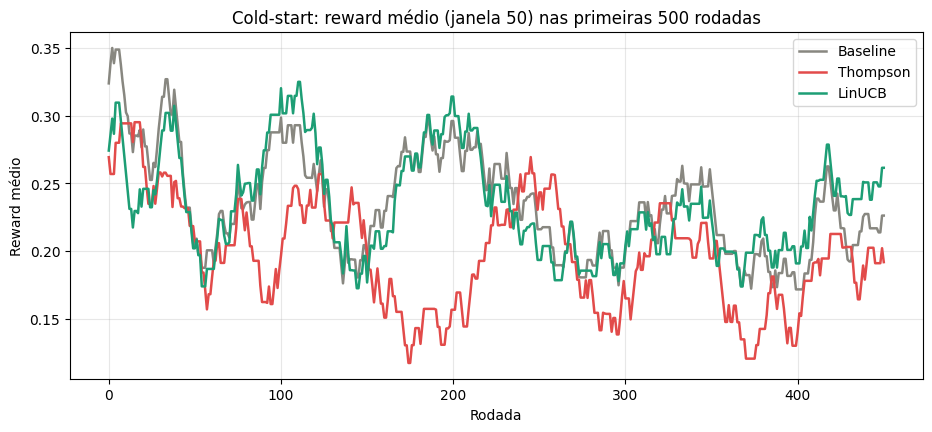

In [19]:
win = 50
plt.figure(figsize=(11,4.5))

for name,kind in [('Baseline','det'),('Thompson','ts'),('LinUCB','linucb')]:
    rps = reward_per_step(kind)
    mov = np.convolve(rps, np.ones(win)/win, mode='valid')
    plt.plot(mov, label=name, color=cores[name], lw=1.8)
    
plt.title(f'Cold-start: reward médio (janela {win}) nas primeiras {WARM} rodadas')
plt.xlabel('Rodada'); plt.ylabel('Reward médio'); plt.legend(); plt.grid(alpha=0.3); plt.show()